In [36]:
import os, yaml, sys
import torch
from einops import reduce, rearrange
import matplotlib.pyplot as plt
import numpy as np
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.image_processing.utils import load_timm_model, load_torchvision_model, get_relevant_output_layers, get_activation
from useful_stuff.general_utils.utils import get_device, get_module_by_path
device = get_device()

In [48]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    model_name = "alexnet";
    pkg = 'torchvision'
    input_size = 224
    pooling = 'all'
cfg = Cfg()

In [32]:
if cfg.pkg == 'timm':
    model = load_timm_model(cfg.model_name, device)
elif cfg.pkg == 'torchvision':
    model = load_torchvision_model(cfg.model_name, device)

In [33]:
layers = get_relevant_output_layers(cfg.model_name, pkg=cfg.pkg)

In [34]:
layers[0]

'features.0'

In [ ]:
from torchvision.models.feature_extraction import create_feature_extractor
def load_model(model_name: str, pkg: str, device: str, img_size: int=384, weights_type: str='DEFAULT'):
    if pkg == 'timm':
        model = load_timm_model(model_name, device, img_size=img_size)
    elif pkg == 'torchvision':    
        model = load_torchvision_model(model_name, device, img_size=img_size, weights_type=weights_type)
    else:
        raise ValueError(f"{pkg=} is not currently supported") # TODO ADD HF
    # end if pkg == 'timm':
    return model
# EOF

class ANN():
    def __init__(self, model_name: str, pkg: str, img_size: int):
        self.model_name = model_name
        self.pkg = pkg
        self.img_size = img_size
        self.device = get_device(verbose=True)
        self.model = load_model(model_name, pkg, self.device, img_size=img_size)
        self.relevant_layers = get_relevant_output_layers(model_name)
    # EOF
    # --- GETTERS ---
    # --- SETTERS ---
    # --- OTHER METHODS ---
    def create_feature_extractor(self, layer_names: list[str]): # if using the feature extractor, you don't have the immediate pooling, while for forward hook you do
        feature_extractor = create_feature_extractor(
            self.model, return_nodes=layer_names
        ).to(self.device) 
        self.feature_extractor = feature_extractor
        return feature_extractor
    # EOF

    def apply_feature_extractor(self, pooling):
        "aaa" # TODO do something that is similar to the result of hooks

    def create_forward_hook(self, pooling: str, layer_names: list[str]=None):
        self.clear_hooks()
        if layer_names is None:
            layer_names = self.relevant_layers
        # end if layer_names is None:
        features = {}
        handles = {}
        for l in layer_names:
            module = get_module_by_path(self.model, l)
            h = module.register_forward_hook(get_activation(l, features, pooling))
            handles[l] = h
        # end for l in layer_names:
        self.handles = handles
        return features, handles
    # EOF
    
    def clear_hooks(self):
        for m in self.model.modules():
            m._forward_hooks.clear()
        # end for m in model.modules():
        self.handles = {}
    # EOF








In [64]:
m = ANN(cfg.model_name, cfg.pkg,  224)

18:48:21 - device being used: mps


In [65]:
f, h = m.create_forward_hook(cfg.pooling)

In [69]:
with torch.no_grad():
    o = m.model(input_tensor)

In [71]:
print(f['classifier.2'].shape)

torch.Size([1, 4096])


In [43]:
from torchvision import transforms
from PIL import Image

# Load a sample image and preprocess it for AlexNet
import urllib.request

# Download a sample image
url = "https://www.python.org/static/community_logos/python-logo.png"
urllib.request.urlretrieve(url, "sample_image.jpg")
image = Image.open("sample_image.jpg")

# Define preprocessing for AlexNet (ImageNet normalization)
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Preprocess and add batch dimension
input_tensor = preprocess(image).unsqueeze(0).to(device)

# Forward pass
with torch.no_grad():
    output = model(input_tensor)

print("Output shape:", output.shape)
print("Predicted class:", output.argmax(dim=1).item())

# Check captured features
for layer_name, feature in features.items():
    print(f"{layer_name}: {feature.shape}")

Output shape: torch.Size([1, 1000])
Predicted class: 784
features.0: torch.Size([1, 193600])
features.4: torch.Size([1, 139968])
features.7: torch.Size([1, 64896])
features.9: torch.Size([1, 43264])
features.11: torch.Size([1, 43264])
classifier.2: torch.Size([1, 4096])
classifier.5: torch.Size([1, 4096])


In [6]:
# Dictionary to store intermediate features
features = {}
layer_name = "layer.0.mlp.down_proj"
module = get_module_by_path(model, layer_name)
module._forward_hooks.clear()
handle = module.register_forward_hook(get_activation(layer_name, features, 'all'))

# Run forward pass
with torch.no_grad():
    outputs = model(**inputs)
# Access features
print(features[layer_name].shape)

torch.Size([1, 77184])


TypeError: Invalid shape (1, 3, 224, 224) for image data

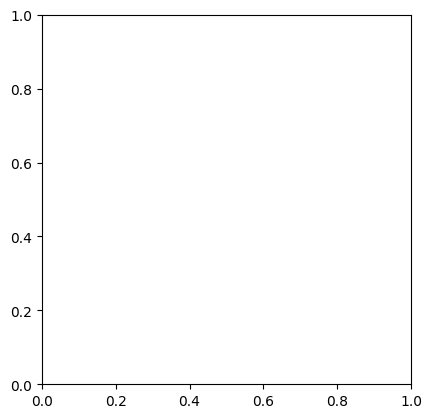

In [ ]:

plt.imshow(np.squeeze(inputs['pixel_values'].cpu()))
# type(inputs)

In [7]:
dir(model)

['T_destination',
 '__annotate_func__',
 '__annotations_cache__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_adjust_missing_and_unexpected_keys',
 '_apply',
 '_auto_class',
 '_backward_compatibility_gradient_checkpointing',
 '_backward_hooks',
 '_backward_pre_hooks',
 '_buffers',
 '_call_impl',
 '_can_compile_fullgraph',
 '_can_record_outputs',
 '_can_set_attn_implementation',
 '_check_and_adjust_attn_implementation',
 '_checkpoint_conversion_mapping',
 '_compiled_call_impl',
 '_convert_head_mask_to_5d',
 '_copy_lm_head_original_to_resized',
 '_create_rep

In [8]:
# Print model modules and parameter shapes (uses existing `model` and `torch` from the notebook)
def print_model_layer_shapes(model):
    total_params = 0
    trainable_params = 0

    for module_name, module in model.named_modules():
        # skip the top-level empty name unless it has no parent info to show
        params = list(module.named_parameters(recurse=False))
        if not params:
            continue

        print(f"Module: '{module_name}' ({module.__class__.__name__})")
        for p_name, p in params:
            shape = tuple(p.shape)
            numel = p.numel()
            total_params += numel
            if p.requires_grad:
                trainable_params += numel
            print(f"  param: {p_name:20s} shape={str(shape):20s} numel={numel:10d} dtype={p.dtype}")
        print()

    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {trainable_params:,}")

# Run the printer
print_model_layer_shapes(model)

Module: 'embeddings' (DINOv3ViTEmbeddings)
  param: cls_token            shape=(1, 1, 384)          numel=       384 dtype=torch.float16
  param: mask_token           shape=(1, 1, 384)          numel=       384 dtype=torch.float16
  param: register_tokens      shape=(1, 4, 384)          numel=      1536 dtype=torch.float16

Module: 'embeddings.patch_embeddings' (Conv2d)
  param: weight               shape=(384, 3, 16, 16)     numel=    294912 dtype=torch.float16
  param: bias                 shape=(384,)               numel=       384 dtype=torch.float16

Module: 'layer.0.norm1' (LayerNorm)
  param: weight               shape=(384,)               numel=       384 dtype=torch.float16
  param: bias                 shape=(384,)               numel=       384 dtype=torch.float16

Module: 'layer.0.attention.k_proj' (Linear)
  param: weight               shape=(384, 384)           numel=    147456 dtype=torch.float16

Module: 'layer.0.attention.v_proj' (Linear)
  param: weight               

In [9]:
# Dictionary to store features
features = {}

def hook_fn(module, input, output):
    features["layer0_scale1"] = output.detach()

# Register hook
target_layer = model.layer[0].layer_scale1
hook_handle = target_layer.register_forward_hook(hook_fn)

In [10]:
print(inputs['pixel_values'].shape)

torch.Size([1, 3, 224, 224])


In [11]:
inputs = processor(images=image, return_tensors="pt").to(model.device)

with torch.inference_mode():    
    outputs = model(**inputs)

# Extract the saved feature
feat = features["layer0_scale1"]
print("Hooked feature shape:", feat.shape)

Hooked feature shape: torch.Size([1, 201, 384])
